# Scenario 1 – Bagging (Diabetes Prediction)

## Importing the Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

## Loading the Dataset

In [2]:
df = pd.read_csv('/content/diabetes_bagging.csv')
df.head()

,Glucose,BMI,Age,BloodPressure,Insulin,Outcome
0,182,21.1,45,99,100,1
1,131,35.6,67,92,199,1
2,172,19.6,68,68,234,1
3,94,39.7,21,102,83,0
4,186,35.0,20,113,61,1


## Training the Model

In [3]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Comparing the Accuracy

In [4]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)

In [5]:
bag = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50)
bag.fit(X_train, y_train)
y_pred_bag = bag.predict(X_test)
acc_bag = accuracy_score(y_test, y_pred_bag)

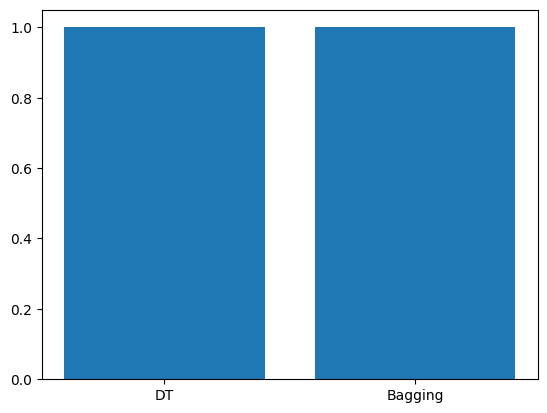

In [6]:
plt.bar(['DT','Bagging'], [acc_dt, acc_bag])
plt.show()

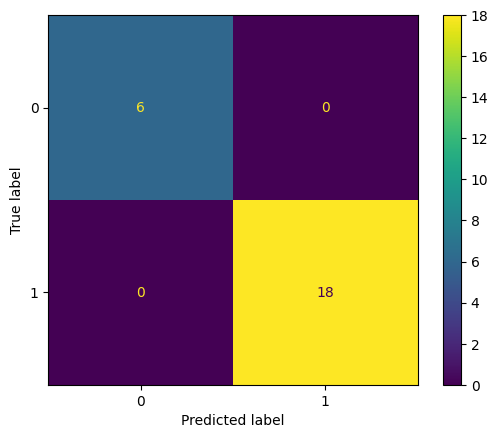

In [7]:
cm = confusion_matrix(y_test, y_pred_bag)
ConfusionMatrixDisplay(cm).plot()
plt.show()